# 1. Importar Librerías Necesarias
Cargamos las librerías principales para procesamiento de imágenes, TensorFlow y manipulación de datos.

In [2]:
#Procesamiento de imagenes

import os
import cv2
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# 2. Verificar GPU
Verificamos si TensorFlow puede acceder a la GPU disponible.

In [3]:
IMG_SIZE = 224

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def procesar_imagen(ruta):
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    # Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Reducir ruido
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # CLAHE (mejorar contraste)
    img = clahe.apply(img)

    # Convertir a RGB (ResNet requiere 3 canales)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # Normalización tipo ImageNet
    img = img / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = (img - mean) / std

    return img

# 3. Función de Procesamiento de Imágenes
Define la función para procesar cada imagen: redimensionar, reducir ruido, mejorar contraste y normalizar.

In [4]:
def cargar_dataset(ruta_dataset):
    X = []
    y = []

    clases = ["cancer", "no_cancer"]

    for idx, clase in enumerate(clases):
        ruta_clase = os.path.join(ruta_dataset, clase)

        print(f"Cargando {clase}...")

        for img_nombre in tqdm(os.listdir(ruta_clase)):
            ruta_img = os.path.join(ruta_clase, img_nombre)

            img = procesar_imagen(ruta_img)

            if img is not None:
                X.append(img)
                y.append(idx)

    return np.array(X), np.array(y)

# 4. Función para Cargar Dataset
Define la función que carga todas las imágenes del dataset y aplica el procesamiento a cada una.

In [5]:
ruta_dataset = "dataset_original"

X, y = cargar_dataset(ruta_dataset)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Cargando cancer...


100%|██████████| 1422/1422 [00:06<00:00, 219.23it/s]


Cargando no_cancer...


100%|██████████| 1314/1314 [00:07<00:00, 165.31it/s]


Shape X: (2736, 224, 224, 3)
Shape y: (2736,)


# 5. Cargar Dataset Original
Cargar todas las imágenes del dataset original y mostrar sus dimensiones.

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (1915, 224, 224, 3)
Val: (410, 224, 224, 3)
Test: (411, 224, 224, 3)


# 6. Dividir Dataset en Train, Validación y Test
Dividir los datos: 70% entrenamiento, 15% validación, 15% test.

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# 7. Configurar Data Augmentation
Define técnicas de aumentación de datos: rotaciones, zoom y flips para mejorar generalización.

In [8]:
import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 8. Importar Librerías Adicionales para Métricas
Importar librerías para visualización, métricas de evaluación y análisis de resultados.

In [9]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: 0.9623115577889447, 1: 1.0407608695652173}


# 9. Calcular Pesos de Clases
Calcular pesos automáticos para balancear clases desbalanceadas en el dataset.

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# 10. Crear Datasets de TensorFlow
Crear datasets optimizados para TensorFlow con batches y aplicar data augmentation al conjunto de entrenamiento.

In [11]:
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE)

train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

# 11. Construir Modelo ResNet50 con Capas Personalizadas
Cargar ResNet50 preentrenado, congelar capas base y agregar capas personalizadas para clasificación binaria.

In [12]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Congelar capas
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

# 12. Compilar Modelo
Compilar el modelo con optimizador Adam, pérdida binary crossentropy y métricas de evaluación.

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

# 13. Configurar Callbacks
Configurar Early Stopping y ReduceLROnPlateau para detener cuando no hay mejora y reducir learning rate.

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

# 14. Entrenar Modelo (Transfer Learning)
Entrenar el modelo con capas base congeladas usando transfer learning (30 épocas máximo).

In [15]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.6653 - loss: 0.6309 - precision: 0.6288 - recall: 0.7402 - val_accuracy: 0.7805 - val_loss: 0.5485 - val_precision: 0.6877 - val_recall: 0.9949 - learning_rate: 1.0000e-04
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7509 - loss: 0.5179 - precision: 0.7064 - recall: 0.8239 - val_accuracy: 0.8073 - val_loss: 0.4852 - val_precision: 0.7252 - val_recall: 0.9645 - learning_rate: 1.0000e-04
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7681 - loss: 0.4937 - precision: 0.7183 - recall: 0.8511 - val_accuracy: 0.8171 - val_loss: 0.4555 - val_precision: 0.7421 - val_recall: 0.9492 - learning_rate: 1.0000e-04
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7676 - loss: 0.4832 - precision: 0.7197 - recall: 0.8457 - val_accuracy: 0.8195 - val_loss: 0.4384 - val_precision: 0.7470 - val_recall: 0.9442 - learning_rate: 1.0000e-04
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accu

# 15. Fine-tuning: Entrenar Últimas Capas
Descongelar últimas 50 capas de ResNet50 y entrenar con learning rate bajo para ajustar el modelo (10 épocas máximo).

In [16]:
# Descongelar últimas capas
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.7222 - loss: 0.5925 - val_accuracy: 0.7317 - val_loss: 0.4980
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.7634 - loss: 0.5180 - val_accuracy: 0.6854 - val_loss: 0.5494
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.7760 - loss: 0.4925 - val_accuracy: 0.7512 - val_loss: 0.4993
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.7906 - loss: 0.4611 - val_accuracy: 0.7805 - val_loss: 0.4655
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.7765 - loss: 0.4622 - val_accuracy: 0.7951 - val_loss: 0.4441


# 16. Evaluar Modelo en Conjunto de Test
Evaluar el modelo final en el conjunto de test y mostrar pérdida y métricas.

In [17]:
model.evaluate(test_dataset)

13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 889ms/step - accuracy: 0.7056 - loss: 0.5152


[0.5151673555374146, 0.7055960893630981]

# 17. Generar Predicciones en Test
Generar predicciones probabilísticas y convertir a etiquetas binarias (umbral 0.5).

In [18]:
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 961ms/step


# 18. Reporte de Clasificación Detallado
Mostrar reporte detallado con precisión, recall, F1-score para cada clase.

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.79      0.74       214
           1       0.73      0.62      0.67       197

    accuracy                           0.71       411
   macro avg       0.71      0.70      0.70       411
weighted avg       0.71      0.71      0.70       411



# 19. Matriz de Confusión
Visualizar la matriz de confusión para ver verdaderos positivos, falsos positivos, etc.

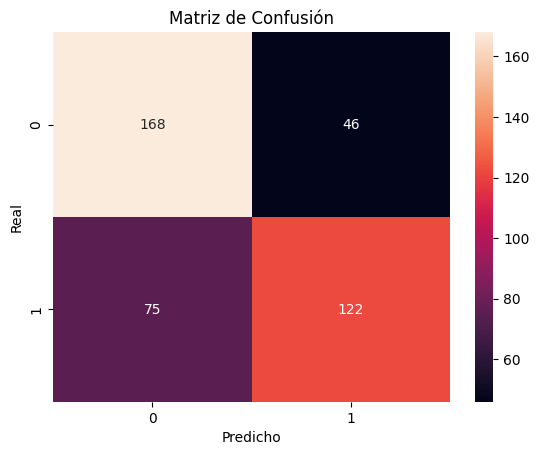

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# 20. Gráficos de Accuracy y Loss
Visualizar el progreso del entrenamiento: accuracy y loss en train vs validación.

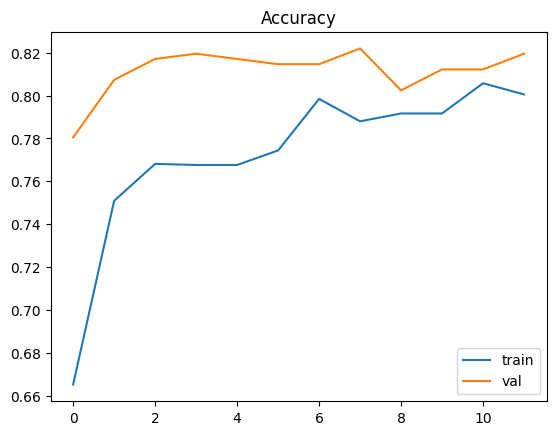

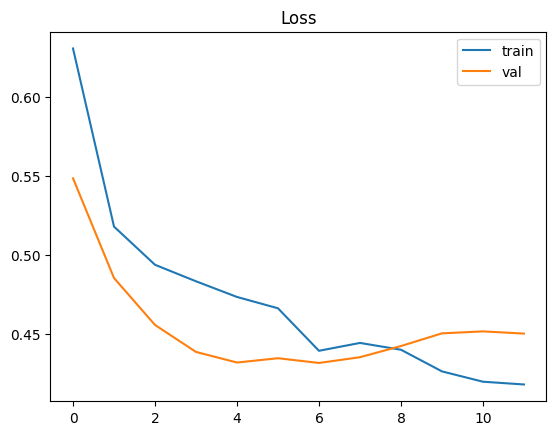

In [21]:
plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()